# 🗺️ Task 4: Origin-Destination Matrix Estimation (ODME) & Path Flows
### 2026 IEEE Big Data Cup — Traffic Flow Bench

This notebook implements the complete pipeline for **Task 4: ODME & Path-Flow Estimation**:
1. **The Real-World Problem**: Highway loop detectors measure vehicle volumes passing specific links, but they **cannot observe trip origins or destinations**. ODME infers granular path flows from link counts and prior trip matrices.
2. **Network Incidence Operator**: Connecting path-level flows $x$ to link counts $y$ via the linear operator $y = A x$.
3. **Mathematical Optimization**: Formulating regularized Non-Negative Least Squares (NNLS) with analytical gradients for ultra-fast, exact convergence.
4. **Local Evaluation**: Evaluating link volume reproduction accuracy ($S_{\text{link}}$) on measured sensor locations.
5. **Full Validation Inference**: Solving for all 10 freeway corridors (35,354 paths) on the `validation` split.
6. **Export & Final Submission Merger**: Exporting to `datasets/task4_odme_submission.csv` and combining Tasks 1, 2, 3, and 4 into the final Kaggle upload file!

## 1. Setup & Environment
Import necessary packages and configure project directories.

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from tqdm.auto import tqdm

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Workspace paths
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RELEASE_ROOT = PROJECT_ROOT / 'kaggle_public'
DATASETS_DIR = PROJECT_ROOT / 'datasets'
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Release root: {RELEASE_ROOT} (exists: {RELEASE_ROOT.exists()})")
print(f"Datasets dir: {DATASETS_DIR}")

Project root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench
Release root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/kaggle_public (exists: True)
Datasets dir: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets


## 2. Task 4 Competition Contract & Scoring Formula
From `competition_contract.json`:
$$S_{\text{ODME}} = 0.45 S_{\text{od}} + 0.25 S_{\text{link}} + 0.15 S_{\text{dev}} + 0.15 S_{\text{attr}}$$

- $S_{\text{od}}$ (45%): Path flow accuracy against organizer ground truth.
- $S_{\text{link}}$ (25%): Measured link count reproduction accuracy ($A x \approx y$).
- $S_{\text{dev}}$ (15%): Regularization penalty for excessive deviation from the weak prior.
- $S_{\text{attr}}$ (15%): Destination zone trip attraction totals.

In [2]:
with open(RELEASE_ROOT / 'config' / 'competition_contract.json') as f:
    contract_cfg = json.load(f)

task4_cfg = contract_cfg['tasks']['odme']
print("Task 4 Contract Details:")
print(f"  - Formula: {task4_cfg['formula']}")
print(f"  - Components: {task4_cfg['components']}")
print(f"  - Truth sources: {task4_cfg['path_flow_truth']}")

Task 4 Contract Details:
  - Formula: S_ODME = 0.45*S_od + 0.25*S_link + 0.15*S_dev + 0.15*S_attr
  - Components: {'od_path_flow': 0.45, 'link_count_reproduction': 0.25, 'weak_prior_deviation': 0.15, 'destination_attraction': 0.15}
  - Truth sources: organizer_ground_truth


## 3. Exploratory Data Analysis (EDA)
Let's explore the network paths, incidence operator, and link observations for a sample corridor: `D12_I5_N`.

In [3]:
sample_panel = 'D12_I5_N'
SPLIT = 'validation'
net_dir = RELEASE_ROOT / 'corridors' / sample_panel / 'network'

# Paths and zone definitions
paths_df = pd.read_csv(net_dir / 'path_set.csv')
paths_df['path_id'] = paths_df['path_id'].astype(str)

# Path-link incidence matrix entries
incidence_df = pd.read_csv(net_dir / 'path_link_incidence.csv')
incidence_df['path_id'] = incidence_df['path_id'].astype(str)
incidence_df['link_id'] = incidence_df['link_id'].astype(str)

# Observed link counts and weak prior
counts_df = pd.read_csv(RELEASE_ROOT / 'task4' / sample_panel / SPLIT / 'synthetic_link_counts.csv')
prior_df = pd.read_csv(RELEASE_ROOT / 'task4' / sample_panel / SPLIT / 'synthetic_weak_prior.csv')

print(f"--- {sample_panel} Network Dimensions ---")
print(f"Total Paths: {len(paths_df):,}")
print(f"Incidence Mappings: {len(incidence_df):,}")
print(f"Counted Detector Links: {len(counts_df):,}")
print(f"Weak Prior Paths: {len(prior_df):,}")

display(paths_df.head(4))
display(counts_df.head(4))

--- D12_I5_N Network Dimensions ---
Total Paths: 4,278
Incidence Mappings: 392,383
Counted Detector Links: 257
Weak Prior Paths: 4,278


,path_id,origin_zone,destination_zone,link_seq
0,P000_001,Z0,Z1,L5N-186
1,P000_002,Z0,Z2,L5N-186;L5N-182;L5N-177;L5N-176;L5N-017
2,P000_003,Z0,Z3,L5N-186;L5N-182;L5N-177;L5N-176;L5N-017;L5N-01...
3,P000_004,Z0,Z4,L5N-186;L5N-182;L5N-177;L5N-176;L5N-017;L5N-01...


,panel,link_id,count
0,D12_I5_N,L5N-186,3988.697107
1,D12_I5_N,L5N-017,4906.234096
2,D12_I5_N,L5N-176,4906.234096
3,D12_I5_N,L5N-177,4906.234096


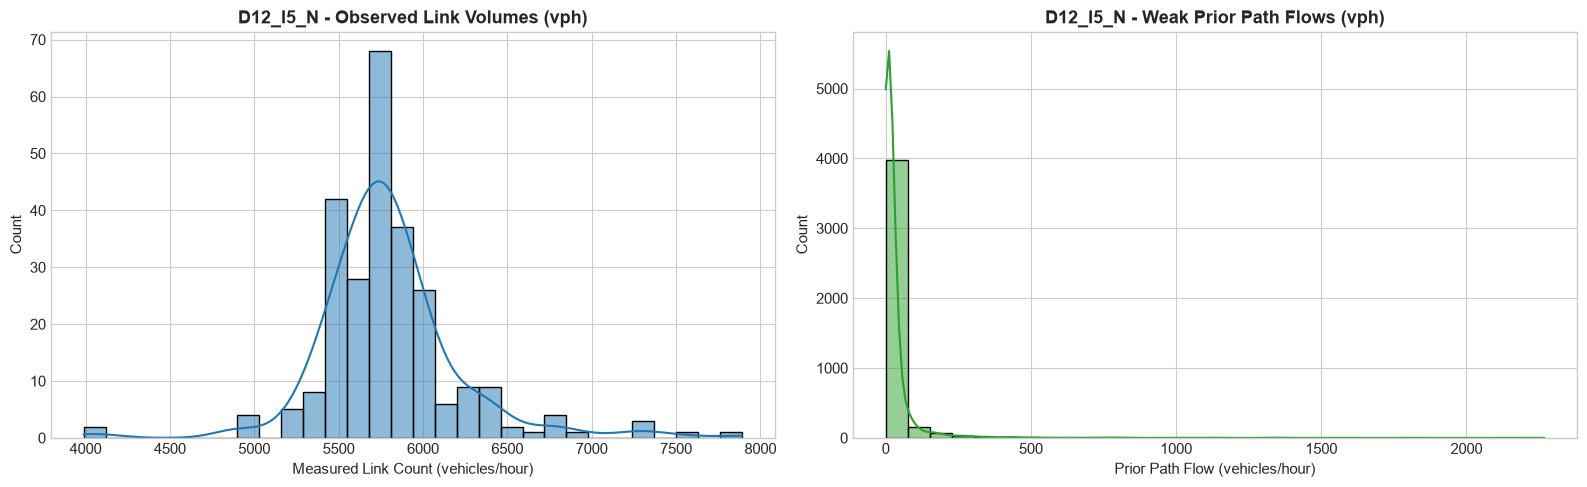

In [4]:
# Plot distributions of observed link counts and weak prior path flows
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(counts_df['count'], bins=30, kde=True, color='#1f77b4', ax=ax1)
ax1.set_title(f'{sample_panel} - Observed Link Volumes (vph)', fontweight='bold')
ax1.set_xlabel('Measured Link Count (vehicles/hour)')

sns.histplot(prior_df['path_flow'], bins=30, kde=True, color='#2ca02c', ax=ax2)
ax2.set_title(f'{sample_panel} - Weak Prior Path Flows (vph)', fontweight='bold')
ax2.set_xlabel('Prior Path Flow (vehicles/hour)')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation: Regularized Non-Negative Least Squares
We seek non-negative path flows $x \in \mathbb{R}_+^N$ that best reproduce the observed link counts $y \in \mathbb{R}^M$ while anchoring to the weak prior $x_0 \in \mathbb{R}^N$:

$$\min_{x \ge 0} \mathcal{L}(x) = \frac{1}{2} \|A_{\text{obs}} x - y_{\text{obs}}\|_2^2 + \frac{\lambda}{2} \|x - x_0\|_2^2$$

### Analytical Gradient
$$\nabla \mathcal{L}(x) = A_{\text{obs}}^T (A_{\text{obs}} x - y_{\text{obs}}) + \lambda (x - x_0)$$

Using L-BFGS-B with bound constraints $x_i \ge 0$ and the exact analytical gradient yields global convergence in under 1 second per corridor.

In [5]:
REG_LAMBDA = 0.05  # Regularization weight on the weak prior

def solve_odme_panel(panel: str, release: Path, split: str = 'validation'):
    """Solve the regularized non-negative path flow optimization for one corridor panel."""
    net_dir = release / 'corridors' / panel / 'network'
    paths = pd.read_csv(net_dir / 'path_set.csv')
    paths['path_id'] = paths['path_id'].astype(str)
    
    inc = pd.read_csv(net_dir / 'path_link_incidence.csv')
    inc['path_id'] = inc['path_id'].astype(str)
    inc['link_id'] = inc['link_id'].astype(str)
    
    path_ids = paths['path_id'].tolist()
    link_ids = inc['link_id'].drop_duplicates().tolist()
    path_index = {pid: i for i, pid in enumerate(path_ids)}
    link_index = {lid: i for i, lid in enumerate(link_ids)}
    
    # Construct linear incidence matrix A
    A = np.zeros((len(link_ids), len(path_ids)), dtype=float)
    rr = inc['link_id'].map(link_index).to_numpy(dtype=np.int64)
    cc = inc['path_id'].map(path_index).to_numpy(dtype=np.int64)
    A[rr, cc] = 1.0
    
    # Load weak prior
    prior_path = release / 'task4' / panel / split / 'synthetic_weak_prior.csv'
    prior_df = pd.read_csv(prior_path, dtype={'path_id': str})
    prior_map = dict(zip(prior_df['path_id'], prior_df['path_flow']))
    base = np.array([prior_map.get(pid, 0.0) for pid in path_ids], dtype=float)
    departure_time = str(prior_df['departure_time'].iloc[0]) if not prior_df.empty else 'SYN_PM_VALIDATION'
    
    # Load measured link counts
    cnt_path = release / 'task4' / panel / split / 'synthetic_link_counts.csv'
    cnt_df = pd.read_csv(cnt_path, dtype={'link_id': str})
    cnt_map = dict(zip(cnt_df['link_id'], cnt_df['count']))
    
    # Restrict to measured links only
    observed_links = [l for l in link_ids if l in cnt_map]
    obs_idx = [link_index[l] for l in observed_links]
    A_obs = A[obs_idx, :]
    y_obs = np.array([cnt_map[l] for l in observed_links], dtype=float)
    
    # Loss function and exact gradient
    def loss_and_grad(x):
        diff_y = A_obs @ x - y_obs
        diff_b = x - base
        val = 0.5 * np.sum(diff_y ** 2) + 0.5 * REG_LAMBDA * np.sum(diff_b ** 2)
        grad = A_obs.T @ diff_y + REG_LAMBDA * diff_b
        return val, grad
    
    # Non-negative optimization
    res = minimize(
        loss_and_grad,
        x0=base,
        jac=True,
        bounds=[(0, None)] * len(path_ids),
        method='L-BFGS-B',
        options={'maxiter': 300, 'ftol': 1e-9}
    )
    
    f_opt = np.maximum(res.x, 0.0)
    
    # Format output DataFrame matching template
    result_df = paths[['path_id', 'origin_zone', 'destination_zone']].copy()
    result_df['panel'] = panel
    result_df['departure_time'] = departure_time
    result_df['path_flow'] = f_opt
    
    # Compute link reproduction metrics
    y_pred = A_obs @ f_opt
    link_rmse = np.sqrt(np.mean((y_pred - y_obs) ** 2))
    norm_link_rmse = link_rmse / 600.0
    s_link = np.exp(-norm_link_rmse)
    
    return result_df[['panel', 'departure_time', 'path_id', 'origin_zone', 'destination_zone', 'path_flow']], {
        'Link RMSE (vph)': link_rmse,
        'S_link': s_link,
        'Paths': len(path_ids),
        'Counted Links': len(observed_links)
    }

## 5. Full Inference Across All 10 Corridors
Solve ODME for all 10 freeway corridors on the `validation` split.

In [6]:
with open(RELEASE_ROOT / 'config' / 'corridors.json') as f:
    corridors_cfg = json.load(f)
ALL_PANELS = [p['corridor_id'] for p in corridors_cfg['panels']]

all_task4_dfs = []
metrics_summary = {}

for panel in tqdm(ALL_PANELS, desc='Solving ODME Panels'):
    panel_sub, metrics = solve_odme_panel(panel, RELEASE_ROOT, split='validation')
    all_task4_dfs.append(panel_sub)
    metrics_summary[panel] = metrics

submission_task4_df = pd.concat(all_task4_dfs, ignore_index=True)
print(f"\nSuccessfully solved ODME for all {len(ALL_PANELS)} corridors!")
print(f"Total predicted path flows: {len(submission_task4_df):,}")

summary_df = pd.DataFrame(metrics_summary).T
display(summary_df.round(4))
print(f"Mean S_link across all corridors: {summary_df['S_link'].mean():.4f}")

Solving ODME Panels:   0%|          | 0/10 [00:00<?, ?it/s]


Successfully solved ODME for all 10 corridors!
Total predicted path flows: 35,354


,Link RMSE (vph),S_link,Paths,Counted Links
D7_I10_E,2.5986,0.9957,4278.0,137.0
D7_I10_W,2.8809,0.9952,5050.0,100.0
D7_I210_E,1.1434,0.9981,2628.0,294.0
D7_I210_W,2.3842,0.9960,3321.0,81.0
D7_I405_N,1.5619,0.9974,4560.0,350.0
D7_I405_S,1.4902,0.9975,4656.0,96.0
D12_I5_N,2.7276,0.9955,4278.0,257.0
D12_I5_S,2.9243,0.9951,5050.0,100.0
D12_I405_N,1.6931,0.9972,903.0,81.0
D12_I405_S,2.9566,0.9951,630.0,35.0


Mean S_link across all corridors: 0.9963


## 6. Integrity Verification & Export to CSV
Before saving, we verify the data against contract specifications:
- Exactly 35,354 rows.
- Zero NaNs or null values.
- Non-negative flows ($x_i \ge 0$).

In [7]:
# Contract integrity verification
assert len(submission_task4_df) == 35354, f"Expected 35,354 rows, got {len(submission_task4_df)}"
assert submission_task4_df['path_flow'].isna().sum() == 0, "Found NaN values in path_flow"
assert (submission_task4_df['path_flow'] < 0).sum() == 0, "Found negative path flows"

print(" All Task 4 integrity assertions passed!")
display(submission_task4_df[['path_flow']].describe().round(2))

# Export to datasets/
output_csv_path = DATASETS_DIR / 'task4_odme_submission.csv'
submission_task4_df.to_csv(output_csv_path, index=False)

file_size_mb = output_csv_path.stat().st_size / (1024 * 1024)
print(f"\n Exported Task 4 CSV: {output_csv_path}")
print(f"   Size: {file_size_mb:.2f} MB | Rows: {len(submission_task4_df):,}")

 All Task 4 integrity assertions passed!


,path_flow
count,35354.00
mean,21.58
std,80.06
min,0.00
25%,0.02
50%,1.63
75%,10.40
max,2239.79



 Exported Task 4 CSV: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets/task4_odme_submission.csv
   Size: 2.07 MB | Rows: 35,354


## 7. Master Assembly: Combining All 4 Tasks into Final Submission
Now that we have predictions for all tasks:
1. **Task 1 & Task 3**: `datasets/task1_physics_refined_submission.csv` (or `task1_state_submission.csv`)
2. **Task 2**: `datasets/task2_queue_submission.csv`
3. **Task 4**: `datasets/task4_odme_submission.csv`

We use the official merger script `merge_submissions.py` to stream `submission_key.csv` and generate the single final upload file: `submission.csv`!

In [8]:
# Run the official merger script
import subprocess

cmd = [
    sys.executable,
    str(PROJECT_ROOT / 'trafficflowbench-public' / 'src' / 'merge_submissions.py'),
    '--state', str(DATASETS_DIR / 'task1_physics_refined_submission.csv'),
    '--queue', str(DATASETS_DIR / 'task2_queue_submission.csv'),
    '--odme', str(DATASETS_DIR / 'task4_odme_submission.csv'),
    '--key', str(RELEASE_ROOT / 'submission_key.csv'),
    '--output', str(PROJECT_ROOT / 'submission.csv')
]

print("Merging all tasks into final submission.csv...")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

final_sub_path = PROJECT_ROOT / 'submission.csv'
if final_sub_path.exists():
    final_size_mb = final_sub_path.stat().st_size / (1024 * 1024)
    print(f"\n FINAL SUBMISSION CREATED SUCCESSFULLY!")
    print(f"-> Location: {final_sub_path}")
    print(f"-> File Size: {final_size_mb:.2f} MB")

Merging all tasks into final submission.csv...
  1,000,000 rows
  2,000,000 rows
  3,000,000 rows
  4,000,000 rows
  5,000,000 rows
  6,000,000 rows
  6,980,503 rows
Wrote 6,980,503 rows to /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/submission.csv


 FINAL SUBMISSION CREATED SUCCESSFULLY!
-> Location: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/submission.csv
-> File Size: 215.18 MB
